<a href="https://colab.research.google.com/github/talaA2/IT362-DataScienceProject/blob/main/Phase%203/Notebooks/Phase3_SVM_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Support Vector Machine (Linear SVM)
TF-IDF unigrams + bigrams with a class-weighted Linear SVM.

In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd
from pathlib import Path

# Works from the repository (Phase 3/Notebooks) and in Colab (reads the copy on GitHub)
DATA_URL = "https://raw.githubusercontent.com/talaA2/IT362-DataScienceProject/main/Phase%203/labeled%20data%20files/"
def data_path(name):
    for folder in [Path("../labeled data files"), Path("Phase 3/labeled data files"), Path(".")]:
        if (folder / name).exists():
            return folder / name
    return DATA_URL + name

youtube = pd.read_csv(data_path("youtube_all_labeled.csv"))
gnews = pd.read_csv(data_path("Gnews_all_labeled.csv"))

print("YouTube shape:", youtube.shape)
print("GNews shape:", gnews.shape)

YouTube shape: (3781, 2)
GNews shape: (110, 2)


In [3]:
# Same combined dataset in every Phase 3 notebook: YouTube first, then GNews
youtube["source"] = "youtube"
gnews["source"] = "gnews"
df = pd.concat([youtube, gnews], ignore_index=True)

df = df.dropna(subset=["text_clean", "label"]).copy()
df["text_clean"] = df["text_clean"].astype(str)
df["label"] = df["label"].astype(int)

print("Final shape:", df.shape)
print("\nLabel distribution (-1 = negative, 0 = neutral, 1 = positive):")
print(df["label"].value_counts())
print("\nSource distribution:")
print(df["source"].value_counts())

Final shape: (3891, 3)

Label distribution (-1 = negative, 0 = neutral, 1 = positive):
label
-1    2260
 0     839
 1     792
Name: count, dtype: int64

Source distribution:
source
youtube    3781
gnews       110
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X = df["text_clean"]
y = df["label"]

# Same 80/20 split in every notebook; stratify keeps the class proportions equal in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 3112
Testing size: 779


In [5]:
svm_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95
    )),
    ("svm", LinearSVC(
        C=1.0,
        random_state=42,
        class_weight="balanced"
    ))
])

In [6]:
svm_model.fit(X_train, y_train)

print("SVM model trained successfully.")

SVM model trained successfully.


In [7]:
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print("SVM Macro F1:", round(macro_f1, 4))
print("Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["negative", "neutral", "positive"]
))

SVM Macro F1: 0.6691
Accuracy: 0.7227

Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.83      0.80       452
     neutral       0.58      0.61      0.59       168
    positive       0.69      0.54      0.61       159

    accuracy                           0.72       779
   macro avg       0.69      0.66      0.67       779
weighted avg       0.72      0.72      0.72       779



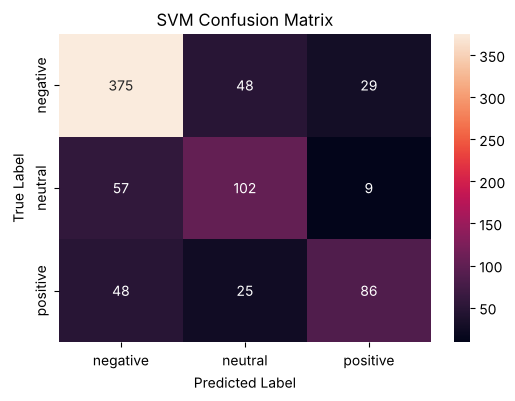

In [8]:
cm = confusion_matrix(y_test, y_pred, labels=[-1, 0, 1])

plt.figure(figsize=(6,4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["negative", "neutral", "positive"],
    yticklabels=["negative", "neutral", "positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("SVM Confusion Matrix")
plt.show()

In [9]:
label_names = {
    -1: "negative",
    0: "neutral",
    1: "positive"
}

In [10]:
RESULTS_DIR = Path("../Summary of results") if Path("../Summary of results").exists() else Path(".")

In [11]:
results = pd.DataFrame({
    "text_clean": X_test.values,
    "actual_label": y_test.values,
    "predicted_label": y_pred
})

results["actual_label_name"] = results["actual_label"].map(label_names)
results["predicted_label_name"] = results["predicted_label"].map(label_names)

results.to_csv(RESULTS_DIR / "svm_test_predictions.csv", index=False)

print("Saved: svm_test_predictions.csv")
results.head()

Saved: svm_test_predictions.csv


,text_clean,actual_label,predicted_label,actual_label_name,predicted_label_name
0,Does not prevent the flu because the do not wa...,0,-1,neutral,negative
1,It made me sick wtf,-1,-1,negative,negative
2,Who dosnt love injecting chemicals into there ...,-1,-1,negative,negative
3,Nudges to clinicians and patients increase the...,1,1,positive,positive
4,"Who knows its a flu shot or covid shot, etc..s...",0,-1,neutral,negative


In [12]:
summary = pd.DataFrame({
    "model": ["Linear SVM"],
    "macro_f1": [macro_f1],
    "accuracy": [accuracy],
    "features": ["TF-IDF unigrams + bigrams"],
    "datasets_used": ["GNews labeled + YouTube labeled"]
})


summary

,model,macro_f1,accuracy,features,datasets_used
0,Linear SVM,0.669082,0.722721,TF-IDF unigrams + bigrams,GNews labeled + YouTube labeled
